In [4]:
import numpy as np
import utils
from env_map import env
from agent import agent
from sarsa import SARSA
from q_learning import QLearning
from test import policy_evaluator
from datetime import datetime
import matplotlib.pyplot as plt

#set this to False if you DO NOT want to see the pygame simulations
#otherwise, all 24 animations will run consequetively
RUN_SIMULATIONS = False

FNAMEs = ['map1', 'map2', 'map3', 'map4']
maps = {}
R_STRATs = ['s1', 's2']
ALPHA = 0.2
NUM_EPISODES = 500
NUM_STEPS = 200
SEED = 96

ABSTRACTION_SIZ = (20,20)
TARGET_POS = (19, 19)
START_POS = (1, 1)

pygame 2.6.1 (SDL 2.28.4, Python 3.12.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


(22, 22)


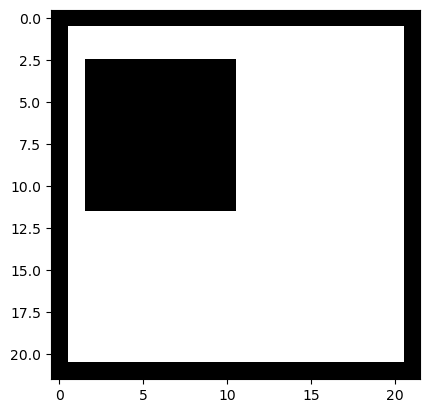

(22, 22)


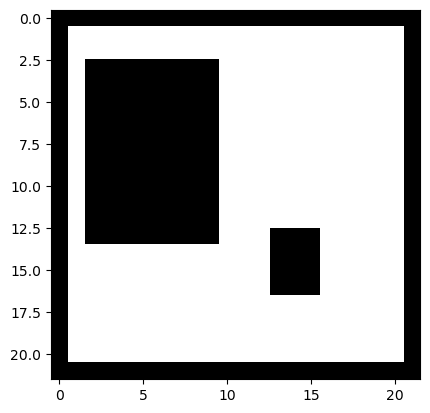

(29, 29)


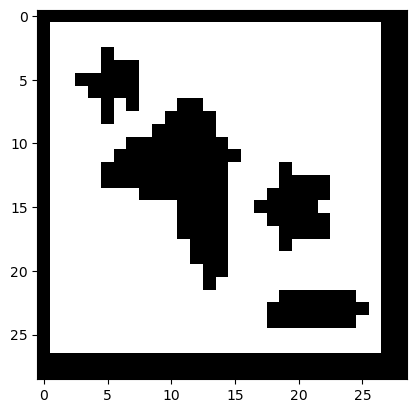

(29, 29)


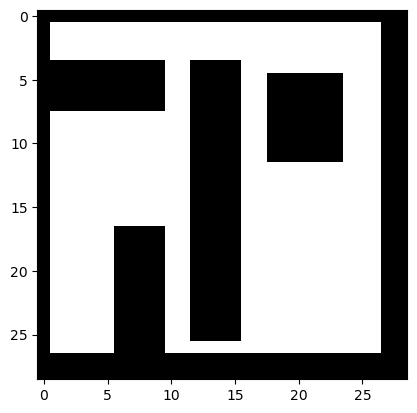

In [5]:
#abstract maps
for f in FNAMEs:
    dim_red = ABSTRACTION_SIZ
    if f == 'map1':
        dim_red = (1,1)
    surface, pooled_map = utils.bmp_to_mat(dim_red, f)
    maps[f] = pooled_map
    
    #show each abstracted map
    plt.imshow(pooled_map, cmap='gray')
    print(pooled_map.shape)
    plt.show()

## Complexity of Map
- [x] SARSA | map1
- [x] SARSA | map2
- [x] SARSA | map3
- [x] SARSA | map4
- [x] Q-Learning | map1
- [x] Q-Learning | map2
- [x] Q-Learning | map3
- [x] Q-Learning | map4

In [7]:
def train_n_test(map, map_name, experiment, method, ts,
                 alpha, gamma, epsilon, r_strat):
    '''
    Params : map : matrix of abstracted map
             map_name : string
             experiment : string 
             method : string - 'SARSA' or 'QLearning'
             ts : string - timestamp
             alpha : float - learning rate
             gamma : float - discount value
             epsilon : float - explore value
             r_strat : string - 's1' or 's2'
             
    Conducts the the whole training and testing process.
    
    Returns : results : dictionary 
              traj : list - the valid trajectory with the shortest path
              episode_reward : list - cumulative rewards
              
    '''
    results = utils.get_results_dict(FNAMEs)

    #initialize the experimental setup
    env_ = env(map, map.shape, r_strat, START_POS, TARGET_POS)
    agent_ = agent(env_, START_POS)

    #init then run learning algorithm
    print(f'Running {method} on {map_name}...')
    if method == 'SARSA':
        sarsa = SARSA(env_, agent_, NUM_EPISODES, NUM_STEPS,
                      epsilon, alpha, gamma, SEED)
        episode_rewards, traj, time_cost, steps_taken = sarsa.run()
    else:
        q_learning = QLearning(env_, agent_, NUM_EPISODES, NUM_STEPS,
                               epsilon, alpha, gamma, SEED)
        episode_rewards, traj, time_cost, steps_taken = q_learning.run()

    #get the episode with the shortest path from training
    #as well as the number of steps taken during that path
    if steps_taken:
        sp_episode = min(steps_taken, key=steps_taken.get)
        sp_val = steps_taken[sp_episode]
    else:
        sp_episode = max(traj.keys())
        sp_val = len(traj[sp_episode])

    #tests the final policies
    print(f'Evaluating {method} policy...\n')
    evaluator = policy_evaluator(agent_, env_, NUM_STEPS, SEED)
    test_acc = evaluator.eval()

    #store all the results
    results[map_name]['timestamp'].append(ts)
    results[map_name]['experiment'].append(experiment)
    results[map_name]['num_episodes'].append(NUM_EPISODES)
    results[map_name]['num_steps'].append(NUM_STEPS)
    results[map_name]['method'].append(method)
    results[map_name]['reward_strat'].append(r_strat)
    results[map_name]['lr'].append(alpha)
    results[map_name]['explore_rate'].append(epsilon)
    results[map_name]['disc_rate'].append(gamma)
    results[map_name]['time_cost'].append(time_cost)
    results[map_name]['shortest_path'].append((sp_episode, sp_val))
    results[map_name]['test_accuracy'].append(test_acc)

    return results, traj[sp_episode], episode_rewards

In [8]:
experiment = 'com'
ts = int(datetime.now().timestamp())
alpha = ALPHA
gamma = 0.9
epsilon = 0.15
r_strat = R_STRATs[0]

for map_name in maps:
    cur_map = maps[map_name]
    
    sarsa_results, traj_s, rewards_s = train_n_test(cur_map, map_name, experiment, 'SARSA',
                                                    ts, alpha, gamma, epsilon, r_strat)
    ql_results, traj_q, rewards_q = train_n_test(cur_map, map_name, experiment, 'QLearning',
                                                 ts, alpha, gamma, epsilon, r_strat)

    
    utils.log(sarsa_results[map_name], f'logs/{experiment}/{map_name}/{ts}/sarsa.csv')
    utils.log(ql_results[map_name], f'logs/{experiment}/{map_name}/{ts}/ql.csv')
    utils.plot_rewards(NUM_EPISODES,rewards_s,f'logs/{experiment}/{map_name}/{ts}/sarsa_rewards_{map_name}.png',
                       title=f'COM: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )
    utils.plot_rewards(NUM_EPISODES,rewards_q,f'logs/{experiment}/{map_name}/{ts}/ql_rewards_{map_name}.png',
                       title=f'COM: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )
    
    if RUN_SIMULATIONS:
        print('Running simulation...\n')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_s,
                      title=f'COM: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_q,
                      title=f'COM: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')
        

Running SARSA on map1...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map1...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map2...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map2...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map3...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map3...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...



## Exploration Rate (map4, γ=0.5)
- [x] SARSA | ε=0
- [x] SARSA | ε=0.5
- [x] SARSA | ε=1
- [x] Q-Learning | ε=0
- [x] Q-Learning | ε=0.5
- [x] Q-Learning | ε=1

In [10]:
experiment = 'exploration_rate'
alpha = ALPHA
er_values = [0, 0.5, 1]
gamma = 0.5
r_strat = R_STRATs[0]
map_name = FNAMEs[3]  #'map4'
cur_map = maps[map_name] 


ts = int(datetime.now().timestamp())

for epsilon in er_values:
    
    sarsa_results, traj_s, rewards_s = train_n_test(cur_map, map_name, experiment, 'SARSA',
                                                    ts, alpha, gamma, epsilon, r_strat)
    ql_results, traj_q, rewards_q = train_n_test(cur_map, map_name, experiment, 'QLearning',
                                                 ts, alpha, gamma, epsilon, r_strat)
    
    utils.log(sarsa_results[map_name], f'logs/{experiment}/{map_name}/{ts}/sarsa.csv')
    utils.log(ql_results[map_name], f'logs/{experiment}/{map_name}/{ts}/ql.csv')
    utils.plot_rewards(NUM_EPISODES,rewards_s,f'logs/{experiment}/{map_name}/{ts}/sarsa_rewards_eps{epsilon}.png',
                       title=f'Exploration: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )
    utils.plot_rewards(NUM_EPISODES,rewards_q,f'logs/{experiment}/{map_name}/{ts}/ql_rewards_eps{epsilon}.png',
                       title=f'Exploration: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )

    if RUN_SIMULATIONS:
        print('Running simulation...\n')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_s,
                      title=f'Exploration: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_q,
                      title=f'Exploration: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...



## Discount Value (map4, ε=0.5)
- [x] SARSA | γ=0.1
- [x] SARSA | γ=0.5
- [x] SARSA | γ=1
- [x] Q-Learning | γ=0.1
- [x] Q-Learning | γ=0.5
- [x] Q-Learning | γ=1

In [12]:
experiment = 'discount_value'
alpha = ALPHA
gamma_values = [0.1, 0.5, 1]
epsilon = 0.5
r_strat = R_STRATs[0]
map_name = FNAMEs[3]  #'map4'
cur_map = maps[map_name] 

ts = int(datetime.now().timestamp())

for gamma in gamma_values:
    
    sarsa_results, traj_s, rewards_s = train_n_test(cur_map, map_name, experiment, 'SARSA',
                                                    ts, alpha, gamma, epsilon, r_strat)
    ql_results, traj_q, rewards_q = train_n_test(cur_map, map_name, experiment, 'QLearning',
                                                 ts, alpha, gamma, epsilon, r_strat)
    
    utils.log(sarsa_results[map_name], f'logs/{experiment}/{map_name}/{ts}/sarsa.csv')
    utils.log(ql_results[map_name], f'logs/{experiment}/{map_name}/{ts}/ql.csv')
    utils.plot_rewards(NUM_EPISODES,rewards_s,f'logs/{experiment}/{map_name}/{ts}/sarsa_rewards_disc{gamma}.png',
                       title=f'Discount: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )
    utils.plot_rewards(NUM_EPISODES,rewards_q,f'logs/{experiment}/{map_name}/{ts}/ql_rewards_disc{gamma}.png',
                       title=f'Discount: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )

    if RUN_SIMULATIONS:
        print('Running simulation...\n')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_s,
                      title=f'Discount: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_q,
                      title=f'Discount: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...



## Reward Strategy (map4, best ε and γ from above)
- [x] SARSA | S1
- [x] SARSA | S2
- [x] Q-Learning | S1
- [x] Q-Learning | S2

In [14]:
experiment = 'reward_strategy'
alpha = ALPHA
gamma = 1
epsilon = 0.5
r_strats = R_STRATs
map_name = FNAMEs[3]  #'map4'
cur_map = maps[map_name] 
id = '-0.05_t_distance'

ts = int(datetime.now().timestamp())

for r_strat in r_strats:
    
    sarsa_results, traj_s, rewards_s = train_n_test(cur_map, map_name, experiment, 'SARSA',
                                                    ts, alpha, gamma, epsilon, r_strat)
    ql_results, traj_q, rewards_q = train_n_test(cur_map, map_name, experiment, 'QLearning',
                                                 ts, alpha, gamma, epsilon, r_strat)

    #log results 
    utils.log(sarsa_results[map_name], f'logs/{experiment}/{map_name}/{ts}_{id}/sarsa.csv')
    utils.log(ql_results[map_name], f'logs/{experiment}/{map_name}/{ts}_{id}/ql.csv')
    utils.plot_rewards(NUM_EPISODES,rewards_s,f'logs/{experiment}/{map_name}/{ts}_{id}/sarsa_rewards_{r_strat}.png',
                       title=f'Discount: SARSA {r_strat},{map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )
    utils.plot_rewards(NUM_EPISODES,rewards_q,f'logs/{experiment}/{map_name}/{ts}_{id}/ql_rewards_{r_strat}.png',
                       title=f'Discount: QLearning {r_strat}, {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}' )

    if RUN_SIMULATIONS:
        print('Running simulation...\n')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_s,
                      title=f'Discount: SARSA {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')
        utils.animate(map_=cur_map, w=cur_map.shape[0], h=cur_map.shape[1],
                      start=START_POS, target=TARGET_POS,
                      traj=traj_q,
                      title=f'Discount: QLearning {map_name}, lr={alpha}, disc={gamma}, eps={epsilon}')
    


Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...

Running SARSA on map4...
0% [##############################] 100%
Evaluating SARSA policy...

Running QLearning on map4...
0% [##############################] 100%
Evaluating QLearning policy...



In [15]:
print('Done!')

Done!
